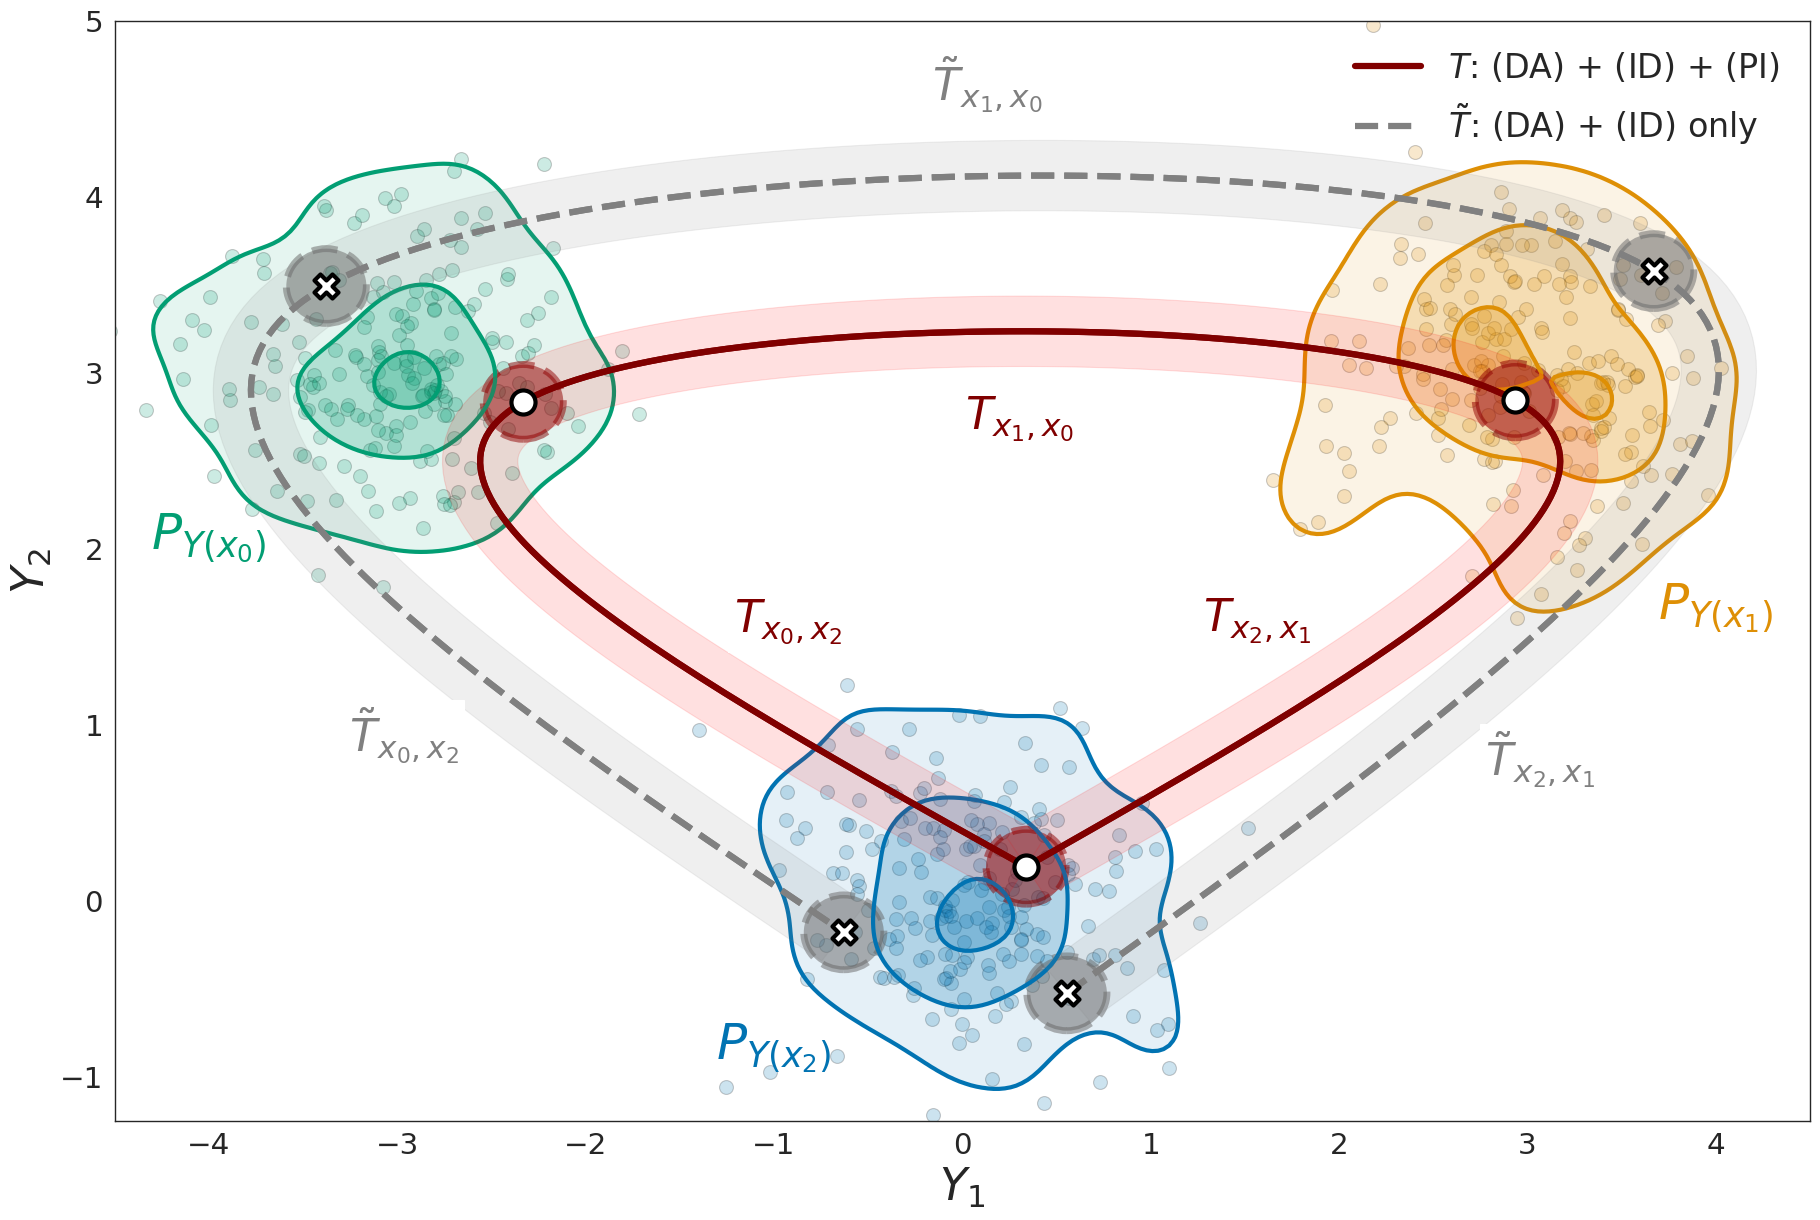

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.interpolate import CubicSpline
from scipy.stats import gaussian_kde, norm, multivariate_normal
import logging
from matplotlib import patches

# Suppress font_manager messages
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

# Seaborn style and colour‐blind palette
sns.set_style("white")
sns.set_context("paper", font_scale=2.4)
palette = sns.color_palette("colorblind", 3)

# -------------------------------  data  ------------------------------------- #
np.random.seed(1)
n_kde = 200
mean_P0 = np.array([0, 0])
mean_P1 = np.array([3, 3])
mean_P2 = np.array([-3, 3])
samples0 = np.random.normal(loc=mean_P0, scale=0.5, size=(n_kde, 2))
samples1 = np.random.normal(loc=mean_P1, scale=0.5, size=(n_kde, 2))
samples2 = np.random.normal(loc=mean_P2, scale=0.5, size=(n_kde, 2))

# Grid for KDE
xmin, xmax, ymin, ymax = -4.5, 4.5, -2, 6
xx, yy = np.meshgrid(np.linspace(xmin, xmax, 300),
                     np.linspace(ymin, ymax, 300))
grid = np.vstack([xx.ravel(), yy.ravel()])

# Compute KDEs
Z0 = gaussian_kde(samples0.T)(grid).reshape(xx.shape)
Z1 = gaussian_kde(samples1.T)(grid).reshape(xx.shape)
Z2 = gaussian_kde(samples2.T)(grid).reshape(xx.shape)

# Contour‐thresholds (fractions of each peak)
fractions = [0.1, 0.5, 0.9]
L0 = [Z0.max()*f for f in fractions]
L1 = [Z1.max()*f for f in fractions]
L2 = [Z2.max()*f for f in fractions]

# ---------------------------- helper: tube polygon -------------------------- #
def tube_polygon(x, y, width):
    """Return polygon (px, py) for a tube of half-width `width` around curve (x,y)."""
    dx = np.gradient(x); dy = np.gradient(y)
    s = np.hypot(dx, dy)
    s[s == 0] = 1.0
    nx, ny = -dy / s, dx / s  # unit normals
    xu, yu = x + width * nx, y + width * ny
    xl, yl = x - width * nx, y - width * ny
    px = np.concatenate([xu, xl[::-1]])
    py = np.concatenate([yu, yl[::-1]])
    return px, py

# --------------------------------- figure ----------------------------------- #
fig, ax = plt.subplots(figsize=(18, 12))

# ----- background scatter -----
for samples, col in zip((samples0, samples1, samples2), palette):
    ax.scatter(samples[:,0], samples[:,1],
               c=[col], s=100, alpha=0.2,
               edgecolor='black')

# ----- progressive HDR shading & contours -----
alphas = [0.1, 0.3, 0.5]   # light→dark for outer→inner
for Z, levels, col in zip((Z0, Z1, Z2), (L0, L1, L2), palette):
    low, mid, high = levels
    ax.contourf(xx, yy, Z, levels=[low, mid], colors=[col], alpha=alphas[0], antialiased=True)
    ax.contourf(xx, yy, Z, levels=[mid, high], colors=[col], alpha=alphas[1], antialiased=True)
    ax.contourf(xx, yy, Z, levels=[high, Z.max()], colors=[col], alpha=alphas[2], antialiased=True)
    ax.contour(xx, yy, Z, levels=[low, mid, high], colors=[col], linestyles='solid', linewidths=3)

# Sample trajectory points (unchanged)
scale = 0.3
P0       = np.random.normal(loc=mean_P0 + np.array([+0.5,0]), scale=scale, size=(1, 2))
P0_inc   = np.random.normal(loc=mean_P0 + np.array([0.5,-0.5]),  scale=scale, size=(1, 2))
P1_cons  = np.random.normal(loc=mean_P1 + np.array([0.0,-0.5]),     scale=scale, size=(1, 2))
P2_cons  = np.random.normal(loc=mean_P2 + np.array([0,0]),  scale=scale, size=(1, 2))
P1_inc   = np.random.normal(loc=mean_P1 + np.array([0.5,0]),     scale=scale, size=(1, 2))
P2_inc   = np.random.normal(loc=mean_P2 + np.array([-0.7,0.7]),  scale=scale, size=(1, 2))
P0_alt   = np.random.normal(loc=mean_P0 + np.array([-0.5,-0.0]), scale=scale, size=(1, 2))

# Time knots and parameter
t_knots = np.array([0, 1/3, 2/3, 1])
t       = np.linspace(0, 1, 200)

# Consistent loop: P0 -> P1_cons -> P2_cons -> P0
knots_c = np.vstack([P0[0], P1_cons[0], P2_cons[0], P0[0]])
cs_xc   = CubicSpline(t_knots, knots_c[:,0], bc_type='natural')
cs_yc   = CubicSpline(t_knots, knots_c[:,1], bc_type='natural')
xc, yc  = cs_xc(t), cs_yc(t)

# Inconsistent loop: P0_inc -> P1_inc -> P2_inc -> P0_alt
knots_i = np.vstack([P0_inc[0], P1_inc[0], P2_inc[0], P0_alt[0]])
cs_xi   = CubicSpline(t_knots, knots_i[:,0], bc_type='natural')
cs_yi   = CubicSpline(t_knots, knots_i[:,1], bc_type='natural')
xi, yi  = cs_xi(t), cs_yi(t)

# ----------------------------- shaded trajectory tubes ---------------------- #
tube_w = 0.2  # visual half-width; adjust as desired (does not change the curve)

# Tube for the consistent (black) path
px, py = tube_polygon(xc, yc, tube_w)
ax.fill(px, py, color="red", alpha=0.12, zorder=2)

# Tube for the inconsistent (grey dashed) path
px, py = tube_polygon(xi, yi, tube_w)
ax.fill(px, py, color="grey", alpha=0.12, zorder=2)

# Draw the original centerlines on top
ax.plot(xc, yc, color='maroon', lw=4.5, label=r'$T$: (DA) + (ID) + (PI)', ls="-", zorder=3)
ax.plot(xi, yi, color="grey", ls='--', lw=4.5, label=r'$\tilde T$: (DA) + (ID) only', zorder=3)

# Markers at waypoints (unchanged)
ax.scatter([P0[0,0], P1_cons[0,0], P2_cons[0,0]],
           [P0[0,1], P1_cons[0,1], P2_cons[0,1]],
           marker='o', s=300, edgecolor='black', facecolor='white', lw=3, zorder=100)
ax.scatter([P0_inc[0,0], P1_inc[0,0], P2_inc[0,0], P0_alt[0,0]],
           [P0_inc[0,1], P1_inc[0,1], P2_inc[0,1], P0_alt[0,1]],
           marker='X', s=300, edgecolor='black', facecolor='white', lw=3, zorder=100)

# Labels for each distribution
ax.text(mean_P0[0]-1.0, mean_P0[1]-0.9, r'$P_{Y(x_2)}$',
        color=palette[0], ha='center', fontsize=36)
ax.text(mean_P1[0]+1.0, mean_P1[1]-1.4, r'$P_{Y(x_1)}$',
        color=palette[1], ha='center', fontsize=36)
ax.text(mean_P2[0]-1.0, mean_P2[1]-1.0, r'$P_{Y(x_0)}$',
        color=palette[2], ha='center', fontsize=36)

# Edge labels (unchanged)
pairs_cons = [(P0, P1_cons, r'$T_{x_2,x_1}$'),
              (P1_cons, P2_cons, r'$T_{x_1,x_0}$'),
              (P2_cons, P0, r'$T_{x_0,x_2}$')]
offset = 0.1

for start, end, label in pairs_cons:
    mid_x = (start[0,0] + end[0,0]) / 2
    mid_y = (start[0,1] + end[0,1]) / 2
    dx = end[0,0] - start[0,0]
    dy = end[0,1] - start[0,1]
    perp = np.array([-dy, dx]); perp = perp / np.linalg.norm(perp)
    mid_x += perp[0] * offset; mid_y += perp[1] * offset
    ax.text(mid_x, mid_y, label, fontsize=32, color='maroon',
            ha='center', va='center', backgroundcolor='white')

pairs_inc = [(P0_inc, P1_inc, r'$\tilde T_{x_2,x_1}$'),
             (P1_inc, P2_inc, r'$\tilde T_{x_1,x_0}$'),
             (P2_inc, P0_alt, r'$\tilde T_{x_0,x_2}$')]
offset = -1.1
t = 0 
for start, end, label in pairs_inc:
    mid_x = (start[0,0] + end[0,0]) / 2
    mid_y = (start[0,1] + end[0,1]) / 2
    dx = end[0,0] - start[0,0]
    dy = end[0,1] - start[0,1]
    perp = np.array([-dy, dx]); perp = perp / np.linalg.norm(perp)
    if t == 1:
        off = offset
    else:
        off = -1.2
    mid_x += perp[0] * off; mid_y += perp[1] * off
    ax.text(mid_x, mid_y, label, fontsize=32, color='grey',
            ha='center', va='center', backgroundcolor='white')
    t += 1

# --------------------- shaded regions around each waypoint ------------------- #
def add_region(center, width, height, edge_color, face_color, ax, angle=0, alpha=0.5, lw=5):
    """Add an ellipse region (positive-measure neighborhood) with dashed edge."""
    e = patches.Ellipse(
        (center[0,0], center[0,1]),
        width=width, height=height, angle=angle,
        facecolor=face_color, edgecolor=edge_color,
        linewidth=lw, linestyle= "dashed",  # dashed boundary
        alpha=alpha
    )
    ax.add_patch(e)

# Consistent path regions (maroon)
W, H = 0.425, 0.425
maroon = (128/255, 0, 0)
add_region(P0,      W, H, edge_color=maroon, face_color=maroon, ax=ax)
add_region(P1_cons, W, H, edge_color=maroon, face_color=maroon, ax=ax)
add_region(P2_cons, W, H, edge_color=maroon, face_color=maroon, ax=ax)

# Inconsistent path regions (gray)
gray = (0.4, 0.4, 0.4)
add_region(P0_inc,  W, H, edge_color=gray, face_color=gray, ax=ax)
add_region(P1_inc,  W, H, edge_color=gray, face_color=gray, ax=ax)
add_region(P2_inc,  W, H, edge_color=gray, face_color=gray, ax=ax)
add_region(P0_alt,  W, H, edge_color=gray, face_color=gray, ax=ax)

def add_arrows_along_line(ax, x, y, n_arrows=3, color="k", lw=3, size=20, clockwise=True):
    """Add arrows along a parametric curve (x,y). If clockwise=True, flip orientation."""
    s = np.linspace(0, len(x)-1, n_arrows+2, dtype=int)[1:-1]  # skip first/last
    for idx in s:
        dx = x[idx+1] - x[idx-1]
        dy = y[idx+1] - y[idx-1]
        if clockwise:
            dx, dy = -dx, -dy  # flip direction
        ax.annotate("",
            xy=(x[idx]+dx, y[idx]+dy),
            xytext=(x[idx], y[idx]),
            arrowprops=dict(
                arrowstyle="-|>,head_width=0.3,head_length=0.4",
                color=color, lw=lw,
                shrinkA=0, shrinkB=0
            ))

# Draw the original centerlines on top
ax.plot(xc, yc, color='maroon', lw=4.5, ls="-", zorder=3)
ax.plot(xi, yi, color="grey", lw=4.5, ls="--", zorder=3)

# Add arrows showing orientation (clockwise)
#add_arrows_along_line(ax, xc, yc, n_arrows=30, color="maroon", lw=5)
#add_arrows_along_line(ax, xi, yi, n_arrows=30, color="grey", lw=5)

# Final styling
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin+0.75, ymax-1)
ax.set_xlabel(r"$Y_1$", fontsize=32)
ax.set_ylabel(r"$Y_2$", fontsize=32)
ax.legend(loc='upper right', frameon=False, fontsize=24)
plt.tight_layout(pad=0)
plt.savefig("CPIproperty_tubes.png", bbox_inches="tight", dpi=300)
plt.show()

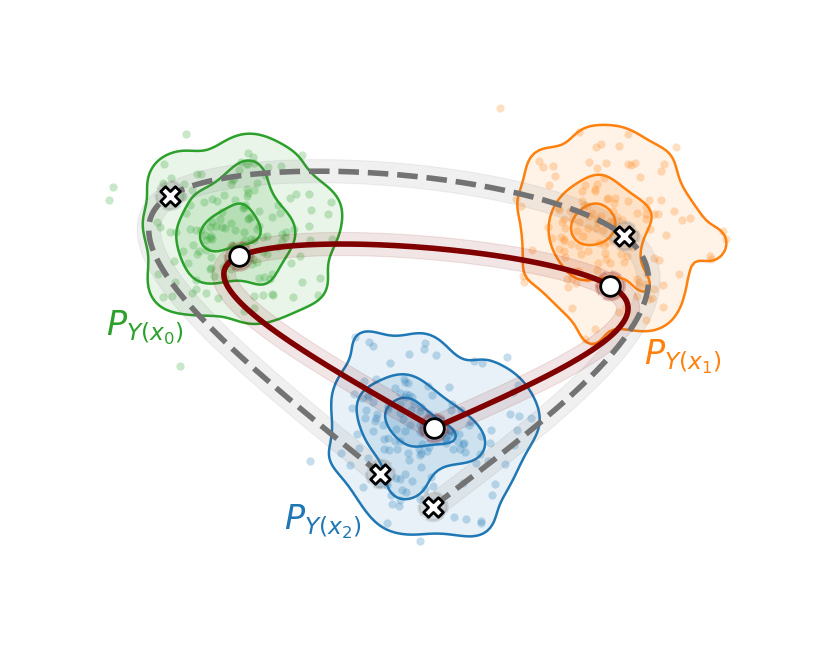

In [54]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline
from scipy.stats import gaussian_kde
import logging
from matplotlib import patches

logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

# -------------------------------  data  ------------------------------------- #
np.random.seed(4)

# ---- Bring the distributions closer together (MAIN CHANGE) ----
mean_P0 = np.array([0.0, 0.0])
mean_P1 = np.array([2.2, 2.4])
mean_P2 = np.array([-2.2, 2.4])

n_kde = 140  # fewer points -> less clutter, faster KDE
sigma = 0.55
samples0 = np.random.normal(loc=mean_P0, scale=sigma, size=(n_kde, 2))
samples1 = np.random.normal(loc=mean_P1, scale=sigma, size=(n_kde, 2))
samples2 = np.random.normal(loc=mean_P2, scale=sigma, size=(n_kde, 2))

# ---- Compute plot bounds from data, with a small margin ----
all_samps = np.vstack([samples0, samples1, samples2])
pad = 1.2
xmin, ymin = all_samps.min(axis=0) - pad
xmax, ymax = all_samps.max(axis=0) + pad

# Grid for KDE (lower resolution is fine for posters)
nx = ny = 220
xx, yy = np.meshgrid(np.linspace(xmin, xmax, nx),
                     np.linspace(ymin, ymax, ny))
grid = np.vstack([xx.ravel(), yy.ravel()])

Z0 = gaussian_kde(samples0.T)(grid).reshape(xx.shape)
Z1 = gaussian_kde(samples1.T)(grid).reshape(xx.shape)
Z2 = gaussian_kde(samples2.T)(grid).reshape(xx.shape)

fractions = [0.12, 0.50, 0.88]
L0 = [Z0.max() * f for f in fractions]
L1 = [Z1.max() * f for f in fractions]
L2 = [Z2.max() * f for f in fractions]

# Choose fixed colors (so you can drop seaborn)
palette = [
    (0.12, 0.47, 0.71),  # blue-ish
    (1.00, 0.50, 0.05),  # orange-ish
    (0.17, 0.63, 0.17),  # green-ish
]
maroon = (128/255, 0, 0)
gray = (0.45, 0.45, 0.45)

def tube_polygon(x, y, width):
    dx = np.gradient(x); dy = np.gradient(y)
    s = np.hypot(dx, dy)
    s[s == 0] = 1.0
    nx, ny = -dy / s, dx / s
    xu, yu = x + width * nx, y + width * ny
    xl, yl = x - width * nx, y - width * ny
    px = np.concatenate([xu, xl[::-1]])
    py = np.concatenate([yu, yl[::-1]])
    return px, py

# --------------------------------- figure ----------------------------------- #
fig, ax = plt.subplots(figsize=(10.5, 7.0))  # smaller but still readable

# ----- background scatter (de-emphasize) -----
for samples, col in zip((samples0, samples1, samples2), palette):
    ax.scatter(samples[:, 0], samples[:, 1],
               c=[col], s=35, alpha=0.25, linewidths=0)  # no edgecolor -> cleaner

# ----- progressive HDR shading & contours -----
alphas = [0.10, 0.22, 0.35]
for Z, levels, col in zip((Z0, Z1, Z2), (L0, L1, L2), palette):
    low, mid, high = levels
    ax.contourf(xx, yy, Z, levels=[low, mid], colors=[col], alpha=alphas[0], antialiased=True)
    ax.contourf(xx, yy, Z, levels=[mid, high], colors=[col], alpha=alphas[1], antialiased=True)
    ax.contourf(xx, yy, Z, levels=[high, Z.max()], colors=[col], alpha=alphas[2], antialiased=True)
    ax.contour(xx, yy, Z, levels=[low, mid, high], colors=[col], linewidths=1.8)

# ------------------- Sample trajectory points (same logic, milder offsets) --- #
scale = 0.22
P0       = np.random.normal(loc=mean_P0 + np.array([+0.35, 0.05]), scale=scale, size=(1, 2))
P0_inc   = np.random.normal(loc=mean_P0 + np.array([0.35, -0.35]), scale=scale, size=(1, 2))
P1_cons  = np.random.normal(loc=mean_P1 + np.array([0.05, -0.35]), scale=scale, size=(1, 2))
P2_cons  = np.random.normal(loc=mean_P2 + np.array([0.00, 0.00]), scale=scale, size=(1, 2))
P1_inc   = np.random.normal(loc=mean_P1 + np.array([0.35, 0.05]), scale=scale, size=(1, 2))
P2_inc   = np.random.normal(loc=mean_P2 + np.array([-0.45, 0.45]), scale=scale, size=(1, 2))
P0_alt   = np.random.normal(loc=mean_P0 + np.array([-0.35, 0.00]), scale=scale, size=(1, 2))

t_knots = np.array([0, 1/3, 2/3, 1])
tt = np.linspace(0, 1, 220)

knots_c = np.vstack([P0[0], P1_cons[0], P2_cons[0], P0[0]])
cs_xc   = CubicSpline(t_knots, knots_c[:, 0], bc_type='natural')
cs_yc   = CubicSpline(t_knots, knots_c[:, 1], bc_type='natural')
xc, yc  = cs_xc(tt), cs_yc(tt)

knots_i = np.vstack([P0_inc[0], P1_inc[0], P2_inc[0], P0_alt[0]])
cs_xi   = CubicSpline(t_knots, knots_i[:, 0], bc_type='natural')
cs_yi   = CubicSpline(t_knots, knots_i[:, 1], bc_type='natural')
xi, yi  = cs_xi(tt), cs_yi(tt)

# ----------------------------- shaded trajectory tubes ---------------------- #
tube_w = 0.14
px, py = tube_polygon(xc, yc, tube_w)
ax.fill(px, py, color=maroon, alpha=0.10, zorder=2)
px, py = tube_polygon(xi, yi, tube_w)
ax.fill(px, py, color=gray, alpha=0.10, zorder=2)

ax.plot(xc, yc, color=maroon, lw=4, zorder=3)
ax.plot(xi, yi, color=gray, lw=4, ls="--", zorder=3)

# Markers
ax.scatter([P0[0,0], P1_cons[0,0], P2_cons[0,0]],
           [P0[0,1], P1_cons[0,1], P2_cons[0,1]],
           marker='o', s=200, edgecolor='black', facecolor='white', lw=2, zorder=5)
ax.scatter([P0_inc[0,0], P1_inc[0,0], P2_inc[0,0], P0_alt[0,0]],
           [P0_inc[0,1], P1_inc[0,1], P2_inc[0,1], P0_alt[0,1]],
           marker='X', s=200, edgecolor='black', facecolor='white', lw=2, zorder=5)

def add_region(center, width, height, edge_color, face_color, ax, angle=0, alpha=0.20, lw=2.2):
    e = patches.Ellipse(
        (center[0,0], center[0,1]),
        width=width, height=height, angle=angle,
        facecolor=face_color, edgecolor=edge_color,
        linewidth=lw, linestyle="dashed",
        alpha=alpha
    )
    ax.add_patch(e)

W, H = 0.34, 0.34
for P in [P0, P1_cons, P2_cons]:
    add_region(P, W, H, edge_color=maroon, face_color=maroon, ax=ax)
for P in [P0_inc, P1_inc, P2_inc, P0_alt]:
    add_region(P, W, H, edge_color=gray, face_color=gray, ax=ax)

def add_arrows_along_line(ax, x, y, n_arrows=10, color="k", lw=2.2, clockwise=True):
    idxs = np.linspace(0, len(x)-2, n_arrows+2, dtype=int)[1:-1]
    for idx in idxs:
        dx = x[idx+1] - x[idx-1]
        dy = y[idx+1] - y[idx-1]
        if clockwise:
            dx, dy = -dx, -dy
        ax.annotate("",
            xy=(x[idx] + 0.9*dx, y[idx] + 0.9*dy),
            xytext=(x[idx], y[idx]),
            arrowprops=dict(arrowstyle="-|>", color=color, lw=lw,
                            mutation_scale=14, shrinkA=0, shrinkB=0)
        )

#add_arrows_along_line(ax, xc, yc, n_arrows=10, color=maroon, lw=2.6)
#add_arrows_along_line(ax, xi, yi, n_arrows=10, color=gray, lw=2.6)

# Labels (smaller, closer)
ax.text(mean_P0[0]-1.15, mean_P0[1]-1.15, r'$P_{Y(x_2)}$', color=palette[0], ha='center', fontsize=24)
ax.text(mean_P1[0]+1, mean_P1[1]-1.55, r'$P_{Y(x_1)}$', color=palette[1], ha='center', fontsize=24)
ax.text(mean_P2[0]-1.1, mean_P2[1]-1.2, r'$P_{Y(x_0)}$', color=palette[2], ha='center', fontsize=24)

ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.set_xlabel(r"$Y_1$", fontsize=18)
ax.set_ylabel(r"$Y_2$", fontsize=18)

# Optional: no legend -> less clutter on a poster panel
# ax.legend(loc='upper right', frameon=False, fontsize=14)
ax.axis("off")

ax.set_aspect('equal', adjustable='box')
plt.tight_layout()
plt.savefig("CPIproperty_tubes_compact.pdf", bbox_inches="tight", dpi=300)
plt.show()

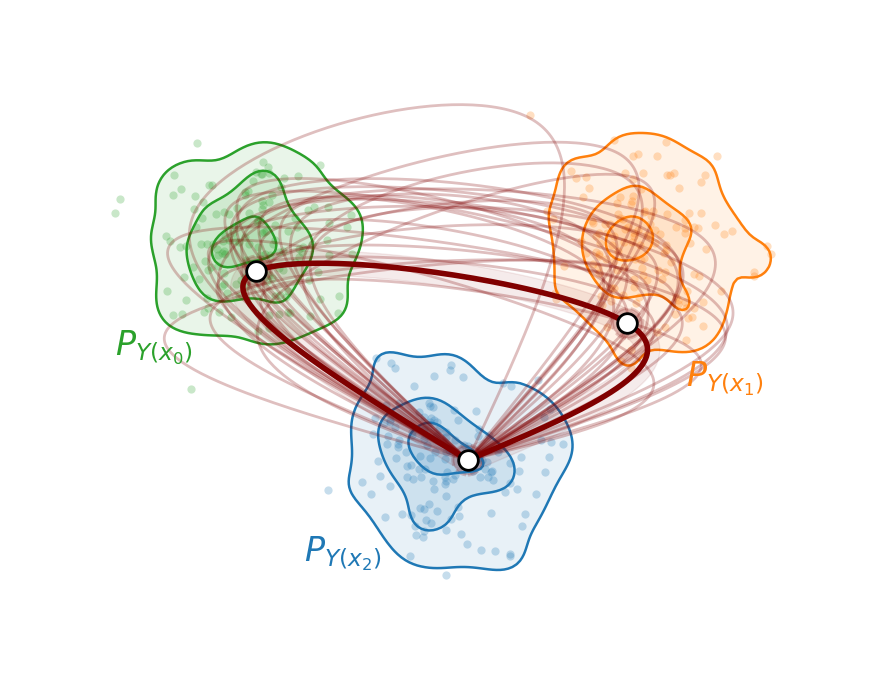

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline
from scipy.stats import gaussian_kde
import logging
from matplotlib import patches

logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

# -------------------------------  data  ------------------------------------- #
np.random.seed(4)

mean_P0 = np.array([0.0, 0.0])
mean_P1 = np.array([2.2, 2.4])
mean_P2 = np.array([-2.2, 2.4])

n_kde = 140
sigma = 0.55
samples0 = np.random.normal(loc=mean_P0, scale=sigma, size=(n_kde, 2))
samples1 = np.random.normal(loc=mean_P1, scale=sigma, size=(n_kde, 2))
samples2 = np.random.normal(loc=mean_P2, scale=sigma, size=(n_kde, 2))

# ---- Compute plot bounds from data, with a small margin ----
all_samps = np.vstack([samples0, samples1, samples2])
pad = 1.2
xmin, ymin = all_samps.min(axis=0) - pad
xmax, ymax = all_samps.max(axis=0) + pad

# Grid for KDE
nx = ny = 220
xx, yy = np.meshgrid(np.linspace(xmin, xmax, nx),
                     np.linspace(ymin, ymax, ny))
grid = np.vstack([xx.ravel(), yy.ravel()])

Z0 = gaussian_kde(samples0.T)(grid).reshape(xx.shape)
Z1 = gaussian_kde(samples1.T)(grid).reshape(xx.shape)
Z2 = gaussian_kde(samples2.T)(grid).reshape(xx.shape)

fractions = [0.12, 0.50, 0.88]
L0 = [Z0.max() * f for f in fractions]
L1 = [Z1.max() * f for f in fractions]
L2 = [Z2.max() * f for f in fractions]

palette = [
    (0.12, 0.47, 0.71),  # blue-ish
    (1.00, 0.50, 0.05),  # orange-ish
    (0.17, 0.63, 0.17),  # green-ish
]
maroon = (128/255, 0, 0)

def tube_polygon(x, y, width):
    dx = np.gradient(x)
    dy = np.gradient(y)
    s = np.hypot(dx, dy)
    s[s == 0] = 1.0
    nx, ny = -dy / s, dx / s
    xu, yu = x + width * nx, y + width * ny
    xl, yl = x - width * nx, y - width * ny
    px = np.concatenate([xu, xl[::-1]])
    py = np.concatenate([yu, yl[::-1]])
    return px, py

# --------------------------------- figure ----------------------------------- #
fig, ax = plt.subplots(figsize=(10.5, 7.0))

# ----- background scatter -----
for samples, col in zip((samples0, samples1, samples2), palette):
    ax.scatter(samples[:, 0], samples[:, 1],
               c=[col], s=35, alpha=0.25, linewidths=0)

# ----- progressive HDR shading & contours -----
alphas = [0.10, 0.22, 0.35]
for Z, levels, col in zip((Z0, Z1, Z2), (L0, L1, L2), palette):
    low, mid, high = levels
    ax.contourf(xx, yy, Z, levels=[low, mid], colors=[col], alpha=alphas[0], antialiased=True)
    ax.contourf(xx, yy, Z, levels=[mid, high], colors=[col], alpha=alphas[1], antialiased=True)
    ax.contourf(xx, yy, Z, levels=[high, Z.max()], colors=[col], alpha=alphas[2], antialiased=True)
    ax.contour(xx, yy, Z, levels=[low, mid, high], colors=[col], linewidths=1.8)

# ------------------- Base point and main highlighted trajectory ------------- #
scale = 0.20

# same starting Y(x0) value for all maroon paths
P0_base = np.random.normal(loc=mean_P0 + np.array([0.35, 0.00]), scale=0.10, size=(1, 2))

# one main bold path
P1_main = np.random.normal(loc=mean_P1 + np.array([0.05, -0.35]), scale=scale, size=(1, 2))
P2_main = np.random.normal(loc=mean_P2 + np.array([0.00, 0.00]), scale=scale, size=(1, 2))

t_knots = np.array([0, 1/3, 2/3, 1])
tt = np.linspace(0, 1, 220)

knots_main = np.vstack([P0_base[0], P1_main[0], P2_main[0], P0_base[0]])
cs_xm = CubicSpline(t_knots, knots_main[:, 0], bc_type='natural')
cs_ym = CubicSpline(t_knots, knots_main[:, 1], bc_type='natural')
xm, ym = cs_xm(tt), cs_ym(tt)

# subtle tube for the main path
tube_w = 0.14
px, py = tube_polygon(xm, ym, tube_w)
ax.fill(px, py, color=maroon, alpha=0.08, zorder=2)

# ------------------- Many faded maroon trajectories ------------------------- #
n_paths = 25

# choose endpoints by sampling from the x1 and x2 clouds
idx1 = np.random.choice(len(samples1), size=n_paths, replace=False)
idx2 = np.random.choice(len(samples2), size=n_paths, replace=False)

for i in range(n_paths):
    P1_i = samples1[idx1[i]] + np.random.normal(scale=0.08, size=2)
    P2_i = samples2[idx2[i]] + np.random.normal(scale=0.08, size=2)

    knots_i = np.vstack([P0_base[0], P1_i, P2_i, P0_base[0]])
    cs_xi = CubicSpline(t_knots, knots_i[:, 0], bc_type='natural')
    cs_yi = CubicSpline(t_knots, knots_i[:, 1], bc_type='natural')
    xi, yi = cs_xi(tt), cs_yi(tt)

    # very faint fan of trajectories
    ax.plot(xi, yi, color=maroon, lw=2.0, alpha=0.25, zorder=2)

# main trajectory on top
ax.plot(xm, ym, color=maroon, lw=4, zorder=4)

# ----------------------------- markers -------------------------------------- #
ax.scatter([P0_base[0, 0], P1_main[0, 0], P2_main[0, 0]],
           [P0_base[0, 1], P1_main[0, 1], P2_main[0, 1]],
           marker='o', s=200, edgecolor='black', facecolor='white', lw=2, zorder=5)

def add_region(center, width, height, edge_color, face_color, ax,
               angle=0, alpha=0.20, lw=2.2):
    e = patches.Ellipse(
        (center[0, 0], center[0, 1]),
        width=width, height=height, angle=angle,
        facecolor=face_color, edgecolor=edge_color,
        linewidth=lw, linestyle="dashed", alpha=alpha
    )
    ax.add_patch(e)

W, H = 0.34, 0.34
for P in [P0_base, P1_main, P2_main]:
    add_region(P, W, H, edge_color=maroon, face_color=maroon, ax=ax)

# Labels
ax.text(mean_P0[0]-1.15, mean_P0[1]-1.15, r'$P_{Y(x_2)}$', color=palette[0], ha='center', fontsize=24)
ax.text(mean_P1[0]+1, mean_P1[1]-1.55, r'$P_{Y(x_1)}$', color=palette[1], ha='center', fontsize=24)
ax.text(mean_P2[0]-1.1, mean_P2[1]-1.2, r'$P_{Y(x_0)}$', color=palette[2], ha='center', fontsize=24)

ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.set_xlabel(r"$Y_1$", fontsize=18)
ax.set_ylabel(r"$Y_2$", fontsize=18)
ax.axis("off")
ax.set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.savefig("CPIproperty_many_maroon_trajectories.pdf", bbox_inches="tight", dpi=300)
plt.show()